In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import learning_curve, LeaveOneOut, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, SelectFromModel, SelectFpr, VarianceThreshold, chi2
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Load, preprocessing

In [2]:
dataset = "C:/Users/tamer/Documents/PhD/ML/enhanced_metabolome.xlsx"
df = pd.read_excel(dataset, sheet_name = 'Paul_50%')
df_val = pd.read_excel(dataset, sheet_name = 'Saqib_50%')

print(df.shape)
print(df_val.shape)

Class_A = 'SN'
Class_B = 'LN'

df = df[(df["Class"] == Class_A) | (df["Class"] == Class_B)]
df_val = df_val[(df_val["Class"] == Class_A) | (df_val["Class"] == Class_B)]

(24, 648)
(12, 648)


In [3]:
def encodage(df):
    code = {
    Class_A : 0,
    Class_B : 1
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [4]:
X_total, y_total = preprocessing(df)
X_val, y_val = preprocessing(df_val)

Class
1    6
0    6
Name: count, dtype: int64
Class
1    3
0    3
Name: count, dtype: int64


In [5]:
print("var before log2 transormation : " , X_total.var(axis=0).mean())
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
X_total = log2_transformer.fit_transform(X_total)
X_val = log2_transformer.fit_transform(X_val)
print("var after log2 transormation : " , X_total.var(axis=0).mean())

var before log2 transormation :  6.378347255133588e+17
var after log2 transormation :  6.050716535554722


In [9]:
def evaluation_CV(model, X, y):

    cv = LeaveOneOut()

    # ===============================
    # Predictions (classes)
    # ===============================
    y_pred = cross_val_predict(
        model,
        X_total,
        y_total,
        cv=cv
    )

    # ===============================
    # Probabilities for ROC
    # ===============================
    y_proba = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:,1]

    # ===============================
    # Confusion matrix
    # ===============================
    print("Confusion matrix:")
    print(confusion_matrix(y, y_pred))

    print("\nAccuracy:")
    print(round(accuracy_score(y, y_pred),3))

    print("\nClassification report:")
    print(classification_report(y, y_pred))

    # ===============================
    # ROC curve
    # ===============================
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)

    # ===============================
    # Plot ROC
    # ===============================
    plt.figure(figsize=(3.2,3.0))

    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', lw=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    #plt.title("ROC curve (LOOCV)")
    plt.legend(loc="lower right")

    plt.tight_layout()

    plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/AUC/AUC-CV.pdf",
    format="pdf",
    bbox_inches="tight"
)
    plt.show()

    return roc_auc

# Définition modèle

In [7]:
vars_ = X_total.var(axis=0)
q = np.quantile(vars_, 0.5) 
selector = VarianceThreshold(threshold = q)
preprocessor = make_pipeline(selector)

LR_L1 = make_pipeline(preprocessor, StandardScaler(), LogisticRegression(penalty='l1', C=10, random_state = 0, solver = 'liblinear'))

# ROC curve

Confusion matrix:
[[6 0]
 [0 6]]

Accuracy:
1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



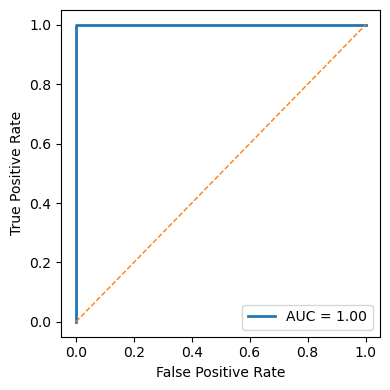

np.float64(1.0)

In [8]:
evaluation_CV(LR_L1, X_total, y_total)